# 01 · Что выгружено из графа

**Зачем этот шаг.** Мы хотим научить модель узнавать слабый сигнал *заранее* —
по тому, что было известно о технологии в прошлом. Поэтому каждый пример для
обучения — это технология на конкретную дату среза T, и всё, что модель о ней
видит, посчитано только по документам, вышедшим до T. Если подмешать хотя бы
один документ из будущего, модель «подсмотрит ответ», и её точность на
проверке окажется фальшивой.

**Что делает выгрузка.** Проходит по сетке дат (до 2005 года раз в год,
2005–2014 раз в полгода, с 2015 года поквартально, плюс сегодняшняя дата) и для
каждой технологии на каждую дату сохраняет:

| Файл | Что внутри | Кому нужно |
|---|---|---|
| `history.csv` | одна строка — технология на дату T: около 170 признаков (сколько документов, как быстро растёт, сколько независимых команд, зрелость, новизна…) | CatBoost — модель на таблице признаков |
| `subgraphs.jsonl` | для той же строки — окружение технологии на два шага: её документы, соседние технологии, организации | HGT — графовая модель |
| `review.reviewer_*.csv` | последние документы технологии с названиями и ссылками | ручная проверка и LLM-разметка |

Команда выгрузки: `python -m lctrend.modeling export-full ...` (выполняется
после слияния дублей, см. раздел 5).

## Что вообще происходит в этом блоке ноутбуков?

1. **01 · выгрузка** — что есть в графе на каждую дату (признаки и окружение технологий);
2. **02 · разметка** — что LLM считает слабым сигналом в каждый год;
3. **03 · выборка** — соединяем 01 и 02 в обучающую таблицу;
4. **04 · обучение** — CatBoost, HGT и их комбинация, метрики;
5. **05 · граф** — записываем итоговую разметку в узлы технологий.

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"))
from lab import *
from IPython.display import display, Markdown

history = read(DATASET_DIR / "history.csv")
history["year"] = history.snapshot_date.str[:4].astype(int)
latest = history.sort_values("snapshot_date").groupby("technology_id").tail(1)
display(Markdown(
    f"Выгрузка: `{DATASET_DIR}`  \n"
    f"**{num(len(history))}** строк по **{num(history.technology_id.nunique())}** технологиям, "
    f"даты среза с {history.snapshot_date.min()} по {history.snapshot_date.max()}."
))

Выгрузка: `artifacts\modeling\2026-09-29-dedup\dataset`  
**62 153** строк по **2 991** технологиям, даты среза с 1960-01-01 по 2026-09-29.

## 1. Сколько данных на самом деле

**Зачем смотрим.** Строк много, но это обманчиво: одна и та же технология
повторяется на десятках дат. Важно понять, сколько в выгрузке *содержательных*
примеров.

**Как читать.** «Активная строка» — дата, к которой за последний год вышел хотя
бы один документ про технологию. Только на таких датах вопрос «слабый ли это
сигнал» имеет смысл; остальные строки — повтор затихшего состояния.

In [2]:
documents = latest.document_count
active = int((history.documents_last_year >= 1).sum())
summary = pd.DataFrame(
    [
        ("Строк «технология × дата»", len(history)),
        ("Технологий", history.technology_id.nunique()),
        ("Дат среза, на которых есть хоть одна технология", history.snapshot_date.nunique()),
        ("Активных строк (был документ за год до даты)", active),
        ("Технологий с одним документом за всю историю", int((documents == 1).sum())),
        ("Технологий с 5 документами и больше", int((documents >= 5).sum())),
        ("Технологий с 20 документами и больше", int((documents >= 20).sum())),
    ],
    columns=["Показатель", "Значение"],
).set_index("Показатель")
display(summary.style.format(num))
display(Markdown(
    f"**Вывод.** У {(documents == 1).mean():.0%} технологий за всю историю ровно один документ. "
    f"Активных строк {num(active)} из {num(len(history))} ({active / len(history):.0%}) — на них и будет "
    "учиться модель. Граф пока редкий: истории у большинства технологий короткие, поэтому любые "
    "метрики качества получатся с широким разбросом."
))

,Значение
Показатель,
Строк «технология × дата»,62 153
Технологий,2 991
"Дат среза, на которых есть хоть одна технология",113
Активных строк (был документ за год до даты),15 604
Технологий с одним документом за всю историю,2 483
Технологий с 5 документами и больше,167
Технологий с 20 документами и больше,42


**Вывод.** У 83% технологий за всю историю ровно один документ. Активных строк 15 604 из 62 153 (25%) — на них и будет учиться модель. Граф пока редкий: истории у большинства технологий короткие, поэтому любые метрики качества получатся с широким разбросом.

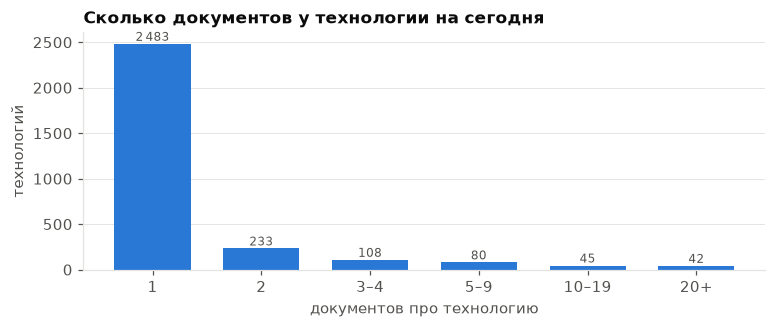

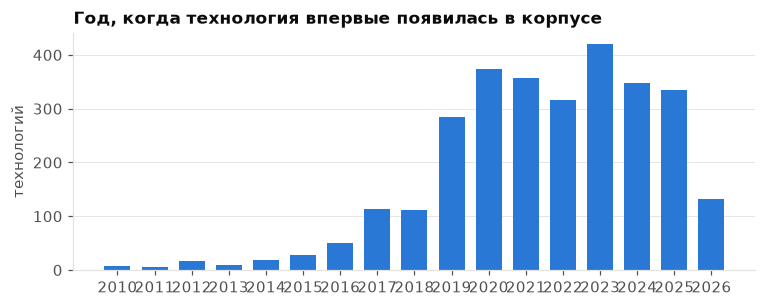

**Вывод.** 2 281 из 2 991 технологий впервые появились с 2020 года: корпус молодой, длинных историй мало.

In [3]:
buckets = pd.cut(documents, [0, 1, 2, 4, 9, 19, float("inf")], labels=["1", "2", "3–4", "5–9", "10–19", "20+"])
by_bucket = buckets.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 2.8))
bar(ax, by_bucket.index.astype(str), by_bucket.values)
for i, v in enumerate(by_bucket.values):
    ax.text(i, v, num(v), ha="center", va="bottom", color=MUTED, fontsize=8)
ax.set_title("Сколько документов у технологии на сегодня")
ax.set_xlabel("документов про технологию")
ax.set_ylabel("технологий")
plt.show()

first_year = latest.first_seen_date.str[:4].astype(int)
by_first = first_year[first_year >= 2010].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 2.8))
bar(ax, by_first.index.astype(str), by_first.values)
ax.set_title("Год, когда технология впервые появилась в корпусе")
ax.set_ylabel("технологий")
plt.show()
display(Markdown(
    f"**Вывод.** {num((first_year >= 2020).sum())} из {num(len(first_year))} технологий впервые "
    "появились с 2020 года: корпус молодой, длинных историй мало."
))

## 2. Как выглядит одна технология во времени

**Зачем смотрим.** Чтобы было видно, что такое «строка выгрузки». Берём
технологию с самой длинной историей: каждая её строка — снимок «что было
известно на эту дату». Ниже — последняя дата каждого года и несколько
ключевых признаков из примерно 170.

**Как читать.** «Документов к дате» только растёт — это накопленная история.
«За последний год» и «рост упоминаний» показывают, жива ли технология сейчас:
рост больше нуля — внимание прибавляется, меньше нуля — угасает.

**Federated Learning** — 43 строк, по одной на дату среза:

,документов к дате,за последний год,независимых групп,университетов,компаний,рост упоминаний за год
год,,,,,,
2016,2,2,1,0,0,1.79
2017,3,1,1,1,0,-1.10
2018,6,3,4,1,0,0.69
2019,23,17,13,21,3,1.87
2020,51,28,19,74,7,0.53
2021,88,37,23,114,8,0.36
2022,142,54,29,156,11,0.40
2023,198,56,29,191,12,-0.04
2024,280,82,32,238,13,0.37


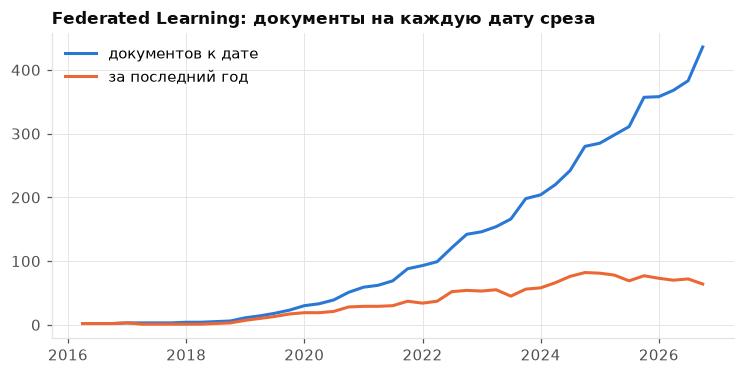

In [4]:
example_id = latest.sort_values("document_count", ascending=False).technology_id.iloc[0]
example = history[history.technology_id == example_id].sort_values("snapshot_date")
name = example.technology.iloc[0]
columns = {
    "document_count": "документов к дате",
    "documents_last_year": "за последний год",
    "independence_group_diversity": "независимых групп",
    "university_count": "университетов",
    "company_count": "компаний",
    "mention_growth_12m": "рост упоминаний за год",
}
yearly = example.groupby("year").tail(1).set_index("year")[list(columns)].rename(columns=columns)
display(Markdown(f"**{name}** — {len(example)} строк, по одной на дату среза:"))
display(yearly.rename_axis("год").tail(12).round(2))

dates = pd.to_datetime(example.snapshot_date)
fig, ax = plt.subplots()
ax.plot(dates, example.document_count, label="документов к дате")
ax.plot(dates, example.documents_last_year, label="за последний год")
ax.set_title(f"{short(name)}: документы на каждую дату среза")
ax.legend(loc="upper left")
plt.show()

## 3. Признаки: что считается и насколько заполнено

**Зачем смотрим.** Признак, который почти всегда пуст, модели бесполезен, а
иногда вреден: она может выучить «пусто — значит старое». Важно видеть, какие
группы признаков реально наполнены.

**Как читать.** Признаки сгруппированы по смыслу. «Средняя заполненность» —
доля строк, где значение известно. Пустое значение означает «данных не было»,
а не ноль. Почти пустые признаки (экономика, вакансии, патенты — таких
источников в графе пока почти нет) шаг 03 отбросит автоматически.

In [5]:
GROUPS = [
    ("Масштаб", ("document_count", "mention_count", "documents_last_year", "_snapshot_pct", "article_count", "repository_count", "reliability_weighted")),
    ("Динамика роста", ("growth", "burst", "persistence", "active_month", "decline", "time_since", "plateau", "acceleration")),
    ("Независимость источников", ("independence", "source_", "convergence", "entropy", "evidence_chain", "lag_days")),
    ("Участники", ("author", "organization", "company", "university", "country", "developer", "user_count", "funder", "hhi", "top_organization", "commercial")),
    ("Достоверность утверждений", ("claim", "accepted_mention", "resolution", "duplicate_content", "evidence_family", "refutation", "attention_evidence", "slot", "mixed_origin")),
    ("Зрелость", ("maturity", "trl", "prototype", "pilot", "implementation", "standard", "release", "commit", "contributor", "patent_", "market_concentration")),
    ("Экономика", ("economic", "grant", "funding", "vacancy", "salary", "hiring", "investment", "market_size", "cost_", "performance_gain", "procurement")),
    ("Новизна и таксономия", ("novelty", "taxonomy", "nearest_known", "centroid", "outlier", "branch", "recombination", "domain_pair")),
    ("Положение в графе", ("degree", "pagerank", "betweenness", "k_core", "community", "structural_hole", "bridge", "neighbor_domain", "new_relation", "parent_technology", "task_count")),
    ("Качество данных", ("fulltext", "metadata_only", "missing", "completeness", "covered", "coverage")),
]
numeric = history.select_dtypes("number").drop(columns=["year"])
group_of = {}
for column in numeric.columns:
    group_of[column] = next((g for g, keys in GROUPS if any(k in column for k in keys)), "Прочее")
filled = numeric.notna().mean()
table = (
    pd.DataFrame({"группа": pd.Series(group_of), "заполнено": filled})
    .groupby("группа")
    .agg(n=("заполнено", "size"), mean=("заполнено", "mean"), empty=("заполнено", lambda s: int((s < 0.01).sum())))
    .sort_values("mean", ascending=False)
)
table.columns = ["признаков", "средняя заполненность", "почти пустых (<1%)"]
display(table.style.format({"средняя заполненность": "{:.0%}"}))
display(Markdown(
    f"**Вывод.** Из {len(filled)} числовых признаков {int((filled < 0.01).sum())} почти пустые. "
    "Хорошо наполнены масштаб, динамика, участники и положение в графе — на них модель и будет опираться."
))

,признаков,средняя заполненность,почти пустых (<1%)
группа,,,
Качество данных,4,100%,0
Положение в графе,14,97%,0
Новизна и таксономия,11,90%,0
Участники,18,77%,0
Достоверность утверждений,15,76%,2
Динамика роста,23,75%,2
Независимость источников,16,66%,5
Масштаб,16,57%,3
Экономика,28,48%,8


**Вывод.** Из 168 числовых признаков 34 почти пустые. Хорошо наполнены масштаб, динамика, участники и положение в графе — на них модель и будет опираться.

## 4. Окружение технологии: подграф на два шага

**Зачем.** Слабый сигнал редко виден по одной технологии: важно, кто ещё о ней
пишет, с чем её упоминают вместе, растут ли соседи. Это «окружение» и есть
подграф, на котором учится графовая модель HGT.

**Как устроен обход.** Идём только через технологии и документы:
технология → её документы → другие технологии из этих документов. Страны,
компании, университеты, организации, области и задачи в подграф попадают,
но через них дальше не идём — иначе через «США» или «Google» каждая
технология оказалась бы соседкой всех остальных. Обзорные статьи с 30 и
более технологиями тоже не пропускают дальше.

Сначала — окружение той же технологии на последнюю дату, по названиям.

In [6]:
from itertools import islice
from lctrend.modeling.dataset.neighbors import iter_samples, neighbor_groups

SOURCE = {"scholarly": "статья", "code": "код", "patent": "патент", "funding": "грант",
          "package_registry": "пакет", "labor_market": "вакансия", "news": "новость"}
names = dict(zip(history.technology_id, history.technology))
last_date = example.snapshot_date.iloc[-1]
sample = next(s for s in iter_samples(DATASET_DIR / "subgraphs.jsonl")
              if s["technology_id"] == example_id and s["snapshot"] == last_date)
nodes = {node["id"]: node for node in sample["nodes"]}
groups = neighbor_groups(sample)
documents_here = [n for n in nodes.values() if n["type"] == "DocumentVersion"]
recent = (pd.DataFrame([{"дата": n["timestamp"], "документ": n.get("title"),
                         "источник": SOURCE.get(n.get("source_family"), n.get("source_family"))}
                        for n in documents_here])
          .drop_duplicates("документ").sort_values("дата", ascending=False).head(8))
hubs = pd.Series([n["type"] for n in nodes.values()
                  if n["type"] in ("Company", "University", "Organization", "Country", "Domain", "Task")]).value_counts()
display(Markdown(f"**{name}** на {last_date}: {len(nodes)} узлов, из них документов {len(documents_here)}. Последние документы:"))
display(recent.style.hide(axis="index"))
comentioned = sorted(groups["comentioned"])
display(Markdown(
    f"**Технологии рядом** ({len(comentioned)}) — упомянуты в тех же документах: "
    + (", ".join(short(names.get(t, t), 50) for t in comentioned[:12]) or "нет")
    + ("…" if len(comentioned) > 12 else "")
    + "  \n**Связанные напрямую** (родитель или потомок): "
    + (", ".join(short(names.get(t, t), 50) for t in sorted(groups["related"])) or "нет")
))
display(hubs.rename({"Company": "компаний", "University": "университетов", "Organization": "организаций",
                     "Country": "стран", "Domain": "областей", "Task": "задач"})
        .rename("тупиковых узлов (через них не идём)").to_frame())

**Federated Learning** на 2026-09-29: 130 узлов, из них документов 33. Последние документы:

дата,документ,источник
2026-09-29,Development of COVID-19 and Cancer Tools with Artificial Intelligence,грант
2026-09-29,"Artificial Intelligence in COVID-19, Procedural Medicine and Cancer",грант
2026-09-29,Development of COVID-19 Imaging Tools with Artificial Intelligence,грант
2026-09-29,Using artificial intelligence and MRI to address limitations in glioblastoma,грант
2026-09-29,Artificial Intelligence from Chest CT to Assess COVID-19 Clinical Trials,грант
2026-09-29,Artificial Intelligence with Chest Imaging in COVID-19 and Isolation and Ventilator Devices for COVID-19,грант
2025-09-27,PRECEDE II Presurgical Cognitive Evaluation Via Digital Clockface Drawing Focusing on Disparities,грант
2025-09-25,Quantum-Resistant AI Models for Next-Generation Cyber Defense,статья


**Технологии рядом** (31) — упомянуты в тех же документах: FLchain architecture, RFA, ENIGMA, Quantum-Resistant AI Architecture, High-performance computing platforms, secure…, Code-based cryptography, Defense strategies for agentic AI, Homomorphic Encryption, rationales, Monitoring scheme for inferring training-data…, Predictive model for energy consumption of Coral…, Deployment with interpreter (e.g., TensorFlow……  
**Связанные напрямую** (родитель или потомок): FLchain architecture

,тупиковых узлов (через них не идём)
организаций,32
университетов,18
областей,7
компаний,5
задач,2
стран,1


Теперь — состав подграфов в целом, по первым 3000 строкам выгрузки.

**Как читать.** Числа — сколько узлов и связей каждого вида в среднем в одном
подграфе. Проверяем заодно, что в подграфы не попали узлы, которых там быть
не должно (авторы, источники, утверждения — они уже учтены в признаках).

In [7]:
from collections import Counter

TYPE = {"Technology": "технологии", "Method": "методы", "Material": "материалы", "DocumentVersion": "документы",
        "Organization": "организации", "University": "университеты", "Company": "компании",
        "Country": "страны", "Domain": "области", "Task": "задачи"}
RELATION = {"MENTIONED_IN": "технология упомянута в документе", "IN_DOMAIN": "документ относится к области",
            "ASSOCIATED_WITH": "у документа есть организация, вуз или компания", "IN_COUNTRY": "документ из страны",
            "SOLVES": "технология решает задачу", "DEVELOPED_BY": "технологию разрабатывает организация",
            "USED_BY": "технологию использует организация", "FUNDED_BY": "технологию финансирует организация",
            "SUBTECHNOLOGY_OF": "технология — часть более общей", "DEVELOPED_IN": "технологию разрабатывают в стране"}
node_types, relations, sizes, forbidden = Counter(), Counter(), [], Counter()
for s in islice(iter_samples(DATASET_DIR / "subgraphs.jsonl"), 3000):
    kinds = [n["type"] for n in s["nodes"]]
    node_types.update(kinds)
    sizes.append(len(kinds))
    forbidden.update(k for k in kinds if k in ("Author", "Source", "Assertion", "Document"))
    relations.update(e["type"] for e in s["edges"])
n = len(sizes)
display(pd.DataFrame({"узлов в среднем": {TYPE.get(t, t): round(c / n, 2) for t, c in node_types.most_common()}}))
display(pd.DataFrame({"связей в среднем": {RELATION.get(r, r): round(c / n, 2) for r, c in relations.most_common(8)}}))
display(Markdown(
    f"**Вывод.** В подграфе в среднем {pd.Series(sizes).median():.0f} узлов (максимум {max(sizes)}), "
    f"документов {node_types['DocumentVersion'] / n:.1f}, соседних технологий {node_types['Technology'] / n - 1:.1f}. "
    f"Лишних узлов {'нет' if not forbidden else 'найдено: ' + str(dict(forbidden))} — обход работает как задумано. "
    "Окружения небольшие: графовой модели есть на что опереться только у части технологий."
))

,узлов в среднем
технологии,2.62
области,2.17
организации,1.87
страны,1.19
документы,1.08
университеты,1.07
компании,0.23
задачи,0.06
методы,0.02


,связей в среднем
"у документа есть организация, вуз или компания",3.17
технология упомянута в документе,2.72
документ относится к области,2.20
документ из страны,1.23
технология решает задачу,0.07
технологию разрабатывает организация,0.03
технологию использует организация,0.03
технология — часть более общей,0.03


**Вывод.** В подграфе в среднем 10 узлов (максимум 58), документов 1.1, соседних технологий 1.6. Лишних узлов нет — обход работает как задумано. Окружения небольшие: графовой модели есть на что опереться только у части технологий.

## 5. Слияние дублей перед выгрузкой

**Зачем.** Одна технология под разными названиями («Explainable AI (XAI)» и
«Explainable Artificial Intelligence») делила бы свою историю между
несколькими узлами: у каждого документов меньше, соседей меньше, и сигнал
размывается. Поэтому перед выгрузкой дубли слиты: дубль отдаёт основному
понятию все связи — упоминания, разработчиков, задачи, родителей.

**Как сливали.** По смысловой близости названий (эмбеддинги):

- **проход 1** — косинус ≥ 0,95, слияние должны подтверждать сами названия;
- **проход 2** — косинус ≥ 0,90, спорные пары решал LLM-судья.

Разные версии (GPT3-13B и GPT3-175B) и пары, которые судья счёл разными, не
сливаются, но на шаге 03 считаются одним семейством.

**Как читать.** «Связей у основных до/после» — сколько связей было у
оставшихся понятий до слияния и сколько стало: цель — меньше одинаковых
узлов, больше связей у каждого.

слито  связей у основных до  связей после  оставлено на проверку  версии (не сливались)
проход                     тип понятий                                                                                                           
проход 1 (0,95, правила)   технологии, методы, материалы    109                  1225          1625                     48                     42
                           задачи                            55                   296           385                      8                      1
                           проблемы                          70                   460           564                     32                      0
                           контексты применения              94                   421           561                     21                     17
проход 2 (0,90, LLM-судья) технологии, методы, материалы    383                  5040          6577                    875                    340
                           задачи                            79                   478           634                    204                      6
                           проблемы                         147                   895          1238                    411                     17
                           контексты применения             119                   644           860                    417                     81

**Вывод.** Всего слито 1 056 понятий, у основных понятий стало на 32% больше связей.

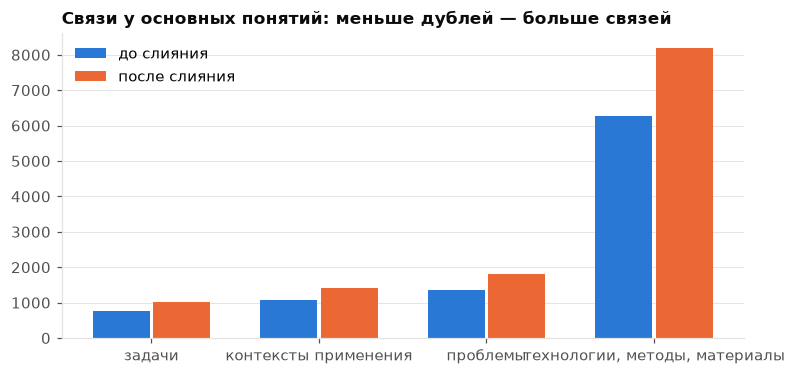

In [7]:
KIND = {"Technology/Method/Material": "технологии, методы, материалы", "Task": "задачи",
        "Problem": "проблемы", "ApplicationContext": "контексты применения"}
passes = {"dedup.json": "проход 1 (0,95, правила)", "dedup-090.json": "проход 2 (0,90, LLM-судья)"}
rows = []
for file, title in passes.items():
    log = json.loads((ROOT / "artifacts/modeling" / file).read_text(encoding="utf-8"))
    for f in log["families"]:
        rows.append({"проход": title, "тип понятий": KIND.get("/".join(f["kinds"]), "/".join(f["kinds"])),
                     "слито": len(f["merged"]), "связей у основных до": f["survivor_links"]["before"],
                     "связей после": f["survivor_links"]["after"], "оставлено на проверку": len(f["review"]),
                     "версии (не сливались)": len(f["held"])})
merges = pd.DataFrame(rows).set_index(["проход", "тип понятий"])
display(merges)
gain = merges["связей после"].sum() / merges["связей у основных до"].sum() - 1
display(Markdown(f"**Вывод.** Всего слито {num(merges['слито'].sum())} понятий, у основных понятий стало на {gain:.0%} больше связей."))

totals = merges.groupby("тип понятий")[["связей у основных до", "связей после"]].sum()
fig, ax = plt.subplots()
positions = range(len(totals))
ax.bar([p - 0.18 for p in positions], totals["связей у основных до"], width=0.34, label="до слияния")
ax.bar([p + 0.18 for p in positions], totals["связей после"], width=0.34, label="после слияния")
ax.set_xticks(list(positions), totals.index)
ax.grid(axis="x", visible=False)
ax.set_title("Связи у основных понятий: меньше дублей — больше связей")
ax.legend()
plt.show()

## Итого

- Выгрузка полная и согласована с графом после слияния дублей; будущие
  документы в признаки не попадают.
- Главное ограничение сейчас — объём данных, а не модель: у большинства
  технологий один документ, окружения маленькие.
- Дальше **02**: что считать слабым сигналом — разметка LLM.